# LIDC-IDRI EDA
데이터 분포, 패치 시각화, reward 분포 분석

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path('..')
df = pd.read_csv(ROOT / 'data/splits/all.csv')
print(f'총 결절: {len(df)}개, 환자: {df.patient_id.nunique()}명')
df.head()

총 결절: 1880개, 환자: 796명


,nodule_id,patient_id,series_uid,n_annotators,malignancy_mean,malignancy_var,reward,path,split
0,LIDC-IDRI-0078_s52353824_n000,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,4,3.75,0.6875,-0.6875,/home/introai26/.agile/user/hsjung/DxMI_Medica...,val
1,LIDC-IDRI-0078_s52353824_n001,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,4,3.75,0.6875,-0.6875,/home/introai26/.agile/user/hsjung/DxMI_Medica...,val
2,LIDC-IDRI-0078_s52353824_n003,LIDC-IDRI-0078,1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102...,4,4.25,0.6875,-0.6875,/home/introai26/.agile/user/hsjung/DxMI_Medica...,val
3,LIDC-IDRI-0069_s54504249_n000,LIDC-IDRI-0069,1.3.6.1.4.1.14519.5.2.1.6279.6001.131939324905...,4,3.25,1.1875,-1.1875,/home/introai26/.agile/user/hsjung/DxMI_Medica...,train
4,LIDC-IDRI-0069_s54504249_n002,LIDC-IDRI-0069,1.3.6.1.4.1.14519.5.2.1.6279.6001.131939324905...,4,3.50,1.2500,-1.2500,/home/introai26/.agile/user/hsjung/DxMI_Medica...,train


## 1. Split 분포

In [2]:
split_stats = df.groupby('split').agg(
    n_nodules=('nodule_id', 'count'),
    n_patients=('patient_id', 'nunique'),
    mean_reward=('reward', 'mean'),
    mean_mal=('malignancy_mean', 'mean'),
).round(3)
print(split_stats)

       n_nodules  n_patients  mean_reward  mean_mal
split                                              
test         178          79       -0.544     2.816
train       1525         638       -0.475     2.792
val          177          79       -0.468     2.876


## 2. Malignancy & Reward 분포

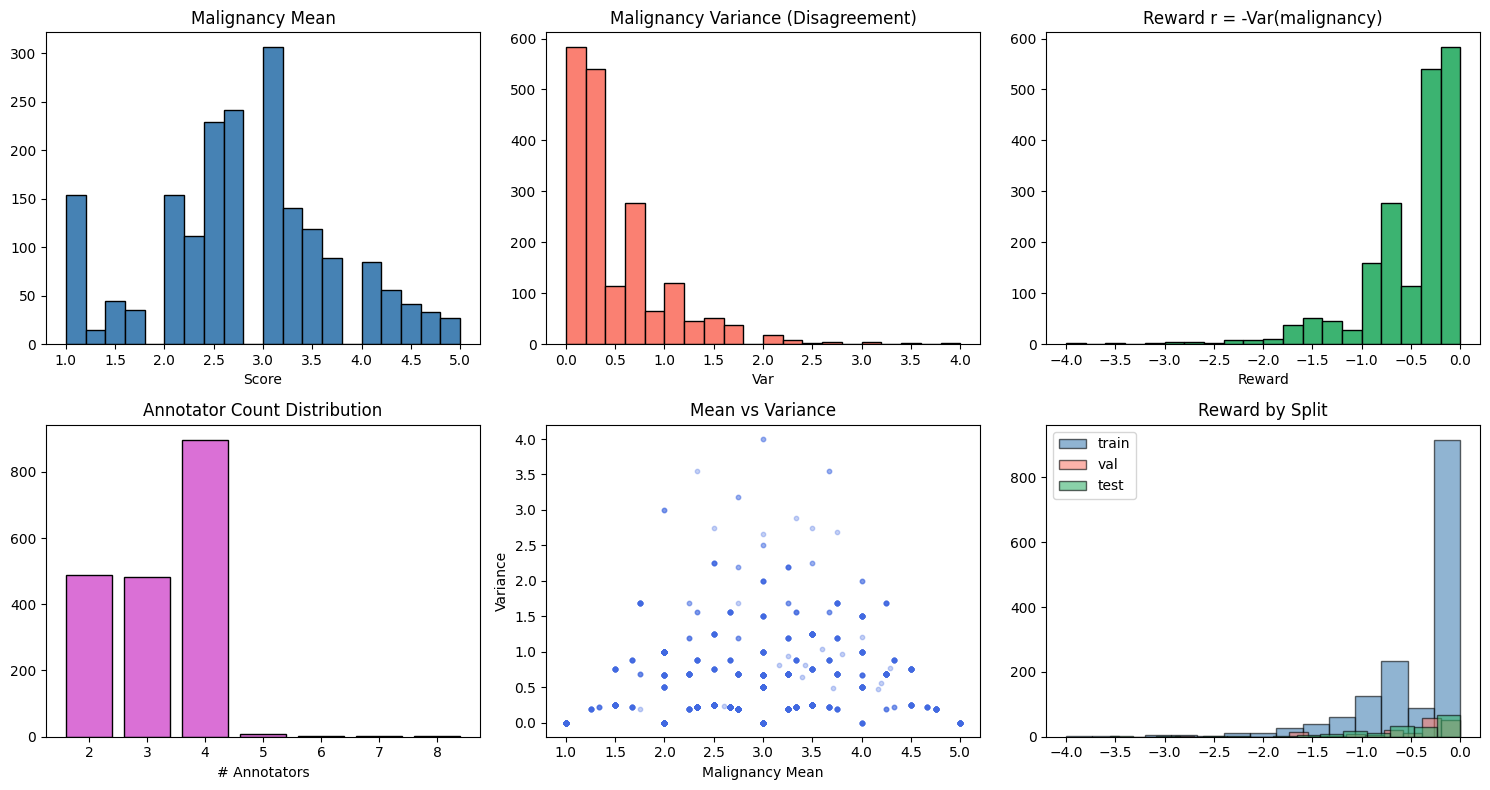

saved: outputs/eda/eda_full.png


In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Malignancy mean
axes[0,0].hist(df.malignancy_mean, bins=20, color='steelblue', edgecolor='k')
axes[0,0].set_title('Malignancy Mean'); axes[0,0].set_xlabel('Score')

# Malignancy var
axes[0,1].hist(df.malignancy_var, bins=20, color='salmon', edgecolor='k')
axes[0,1].set_title('Malignancy Variance (Disagreement)'); axes[0,1].set_xlabel('Var')

# Reward
axes[0,2].hist(df.reward, bins=20, color='mediumseagreen', edgecolor='k')
axes[0,2].set_title('Reward r = -Var(malignancy)'); axes[0,2].set_xlabel('Reward')

# n_annotators
ann_counts = df.n_annotators.value_counts().sort_index()
axes[1,0].bar(ann_counts.index, ann_counts.values, color='orchid', edgecolor='k')
axes[1,0].set_title('Annotator Count Distribution'); axes[1,0].set_xlabel('# Annotators')

# Scatter: malignancy_mean vs malignancy_var
axes[1,1].scatter(df.malignancy_mean, df.malignancy_var, alpha=0.3, s=10, color='royalblue')
axes[1,1].set_title('Mean vs Variance'); axes[1,1].set_xlabel('Malignancy Mean'); axes[1,1].set_ylabel('Variance')

# Split별 reward 분포
colors = {'train': 'steelblue', 'val': 'salmon', 'test': 'mediumseagreen'}
for split, color in colors.items():
    sub = df[df.split == split]
    axes[1,2].hist(sub.reward, bins=15, alpha=0.6, color=color, label=split, edgecolor='k')
axes[1,2].set_title('Reward by Split'); axes[1,2].legend()

plt.tight_layout()
plt.savefig('../outputs/eda/eda_full.png', dpi=150)
plt.show()
print('saved: outputs/eda/eda_full.png')

## 3. 패치 시각화 (샘플 결절)

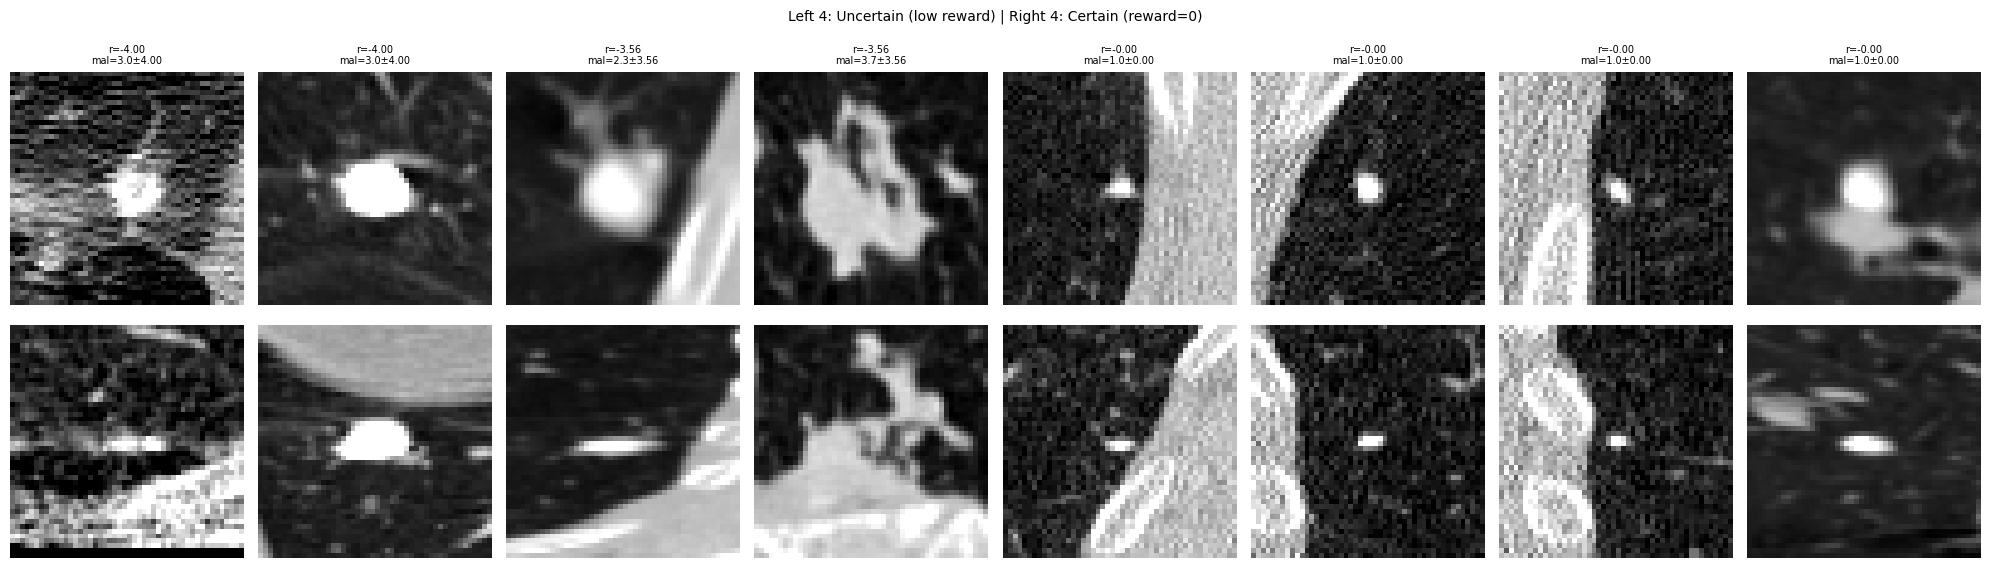

saved: outputs/eda/patch_samples.png


In [4]:
# reward 극단값 결절 시각화 (가장 확실한 vs 가장 불확실한)
df_sorted = df.sort_values('reward')
samples = pd.concat([
    df_sorted.head(4),   # 가장 불확실 (reward 최소)
    df_sorted.tail(4),   # 가장 확실   (reward 최대 = 0)
])

fig, axes = plt.subplots(2, 8, figsize=(20, 6))
for col, (_, row) in enumerate(samples.iterrows()):
    data = np.load(row['path'])
    patch = data['patch']         # (48, 48, 48)
    mid   = patch[24]             # 중앙 슬라이스 (Y-Z plane)
    
    ax = axes[0, col]
    ax.imshow(mid, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"r={row['reward']:.2f}\nmal={row['malignancy_mean']:.1f}±{row['malignancy_var']:.2f}",
                 fontsize=7)
    ax.axis('off')
    
    ax2 = axes[1, col]
    ax2.imshow(patch[:, 24, :], cmap='gray', vmin=0, vmax=1)  # coronal
    ax2.axis('off')

axes[0, 0].set_ylabel('Axial', fontsize=9)
axes[1, 0].set_ylabel('Coronal', fontsize=9)
fig.suptitle('Left 4: Uncertain (low reward) | Right 4: Certain (reward=0)', fontsize=10)
plt.tight_layout()
plt.savefig('../outputs/eda/patch_samples.png', dpi=150)
plt.show()
print('saved: outputs/eda/patch_samples.png')

## 4. 임상 상관관계 사전 확인 (random energy로 null 분포 추정)

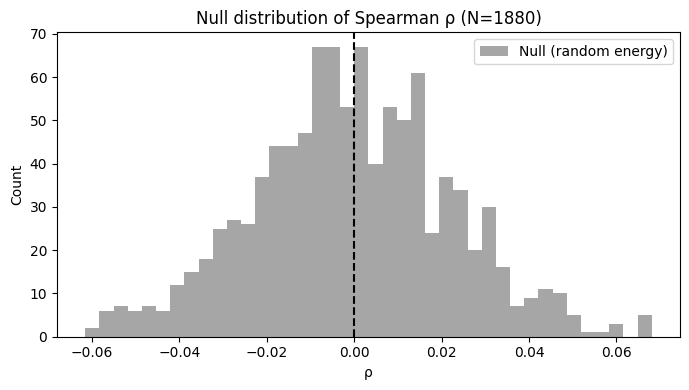

95% CI threshold: |ρ| > 0.0463 → 훈련 후 이 값 초과해야 p<0.05 기대


In [5]:
from scipy.stats import spearmanr
import numpy as np

# 랜덤 에너지 → null 분포
np.random.seed(42)
N = len(df)
null_rhos = [spearmanr(np.random.randn(N), df.malignancy_var.values).statistic
             for _ in range(1000)]

plt.figure(figsize=(7, 4))
plt.hist(null_rhos, bins=40, color='gray', alpha=0.7, label='Null (random energy)')
plt.axvline(0, color='black', linestyle='--')
plt.title(f'Null distribution of Spearman ρ (N={N})')
plt.xlabel('ρ'); plt.ylabel('Count'); plt.legend()
plt.tight_layout()
plt.savefig('../outputs/eda/null_distribution.png', dpi=150)
plt.show()

ci_95 = np.percentile(np.abs(null_rhos), 95)
print(f'95% CI threshold: |ρ| > {ci_95:.4f} → 훈련 후 이 값 초과해야 p<0.05 기대')